# Task-04: Social Media Sentiment Analysis

## Introduction

Sentiment analysis is a technique used to identify the **emotional tone and opinion** expressed in social media content. In this project, social media data is analyzed to classify posts into **positive, negative, and neutral sentiments**.

The analysis helps understand how people feel about different **topics, products, or brands**. Data visualization is then used to identify sentiment patterns, compare opinions, and understand the overall public perception.

## Objective

- Analyze sentiment in social media data.
- Identify positive, negative, and neutral opinions.
- Visualize sentiment patterns and trends.
- Understand overall public opinion toward different topics or brands.

### Importing Libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("twitter_training.csv", header=None)

df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
df.columns = ["ID", "Topic", "Sentiment", "Text"]

df.head()

,ID,Topic,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


# Understand the Dataset

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.info()

Shape: (74682, 4)

Columns:
Index(['ID', 'Topic', 'Sentiment', 'Text'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Topic      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [5]:
df.head(10)

,ID,Topic,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


In [6]:
df.isnull().sum()

ID             0
Topic          0
Sentiment      0
Text         686
dtype: int64

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2700


## Data Cleaning

Duplicate records are removed to avoid counting the same social media posts multiple times and to improve the reliability of the analysis.

In [8]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 2700
Shape after removing duplicates: (71982, 4)


In [9]:
print("Missing Text values:", df["Text"].isnull().sum())

Missing Text values: 326


In [10]:
df = df.dropna(subset=["Text"]).reset_index(drop=True)

print("Shape after removing missing text:", df.shape)

Shape after removing missing text: (71656, 4)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71656 entries, 0 to 71655
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         71656 non-null  int64 
 1   Topic      71656 non-null  object
 2   Sentiment  71656 non-null  object
 3   Text       71656 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.2+ MB


## Sentiment Distribution

The distribution of sentiment labels is analyzed to understand the overall pattern of public opinion in the dataset.

In [12]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

sentiment_percent = df["Sentiment"].value_counts(normalize=True) * 100

print(sentiment_percent.round(2))

Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64
Sentiment
Negative      30.28
Positive      27.51
Neutral       24.71
Irrelevant    17.50
Name: proportion, dtype: float64


### Sentiment Visualization

A bar chart is used to visualize the number of posts belonging to each sentiment category.

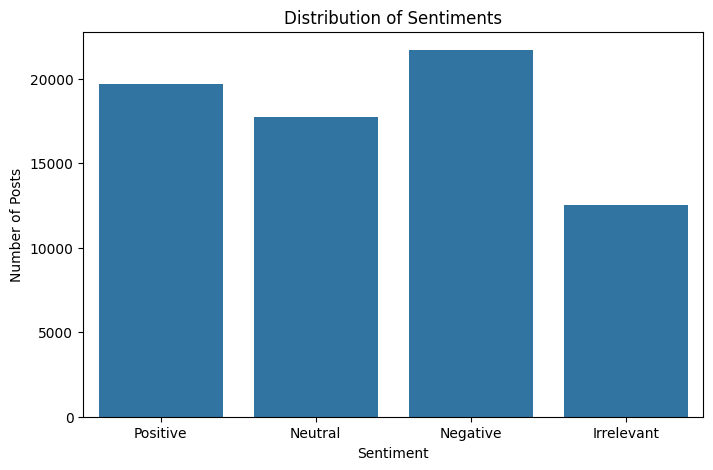

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")

plt.show()

In [14]:
print(sentiment_counts)

Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64


### Interpretation

The sentiment distribution shows that **Negative sentiment is the most common category**, with 21,698 posts. This is followed by Positive sentiment with 19,713 posts and Neutral sentiment with 17,708 posts.

The dataset also contains 12,537 Irrelevant posts, which represents the smallest category.

Overall, the data shows a **slightly negative pattern in public opinion**, as negative posts are more frequent than positive and neutral posts.

## Topic Distribution

The distribution of posts across different topics is analyzed to identify the most frequently discussed topics or brands in the dataset.

In [15]:
topic_counts = df["Topic"].value_counts()

print(topic_counts)

Topic
TomClancysRainbowSix                 2328
Verizon                              2319
MaddenNFL                            2315
CallOfDuty                           2314
Microsoft                            2304
WorldOfCraft                         2300
NBA2K                                2299
LeagueOfLegends                      2296
TomClancysGhostRecon                 2291
Facebook                             2289
ApexLegends                          2278
johnson&johnson                      2257
Battlefield                          2255
Amazon                               2249
CallOfDutyBlackopsColdWar            2242
FIFA                                 2238
Dota2                                2225
Overwatch                            2220
Hearthstone                          2219
HomeDepot                            2216
GrandTheftAuto(GTA)                  2208
Borderlands                          2206
Xbox(Xseries)                        2201
Google                      

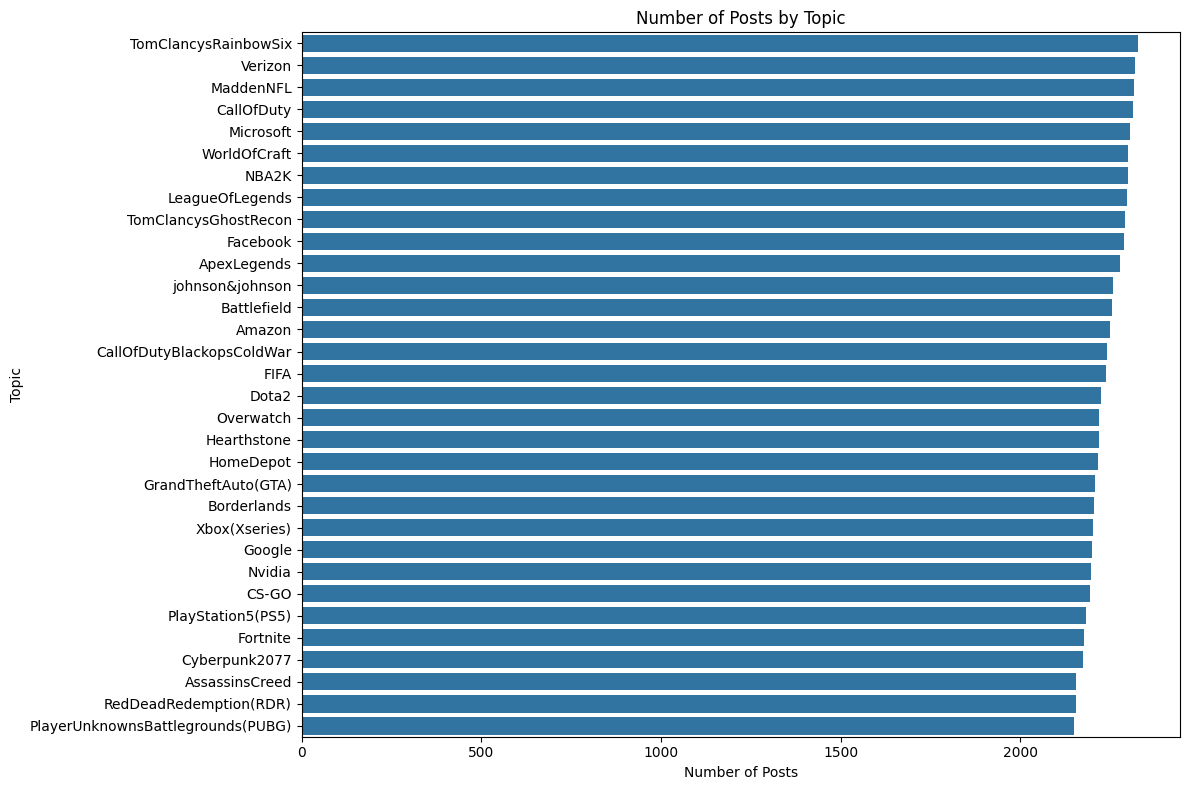

In [16]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=topic_counts.values,
    y=topic_counts.index
)

plt.title("Number of Posts by Topic")
plt.xlabel("Number of Posts")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()

### Interpretation

The topic distribution shows that the dataset contains a relatively balanced number of posts across different topics and brands. **TomClancysRainbowSix** has the highest number of posts, while **PlayerUnknownsBattlegrounds(PUBG)** has one of the lowest.

Overall, the similar number of posts across topics makes it suitable for comparing sentiment patterns between different topics.

## Sentiment by Topic

The sentiment of posts is compared across different topics to understand how public opinion varies between brands, games, and other subjects.


In [17]:
sentiment_topic = pd.crosstab(
    df["Topic"],
    df["Sentiment"]
)

sentiment_topic.head()

Sentiment,Irrelevant,Negative,Neutral,Positive
Topic,,,,
Amazon,185,565,1197,302
ApexLegends,185,574,913,606
AssassinsCreed,256,365,153,1382
Battlefield,907,445,342,561
Borderlands,238,415,581,972


<Figure size 1400x1000 with 0 Axes>

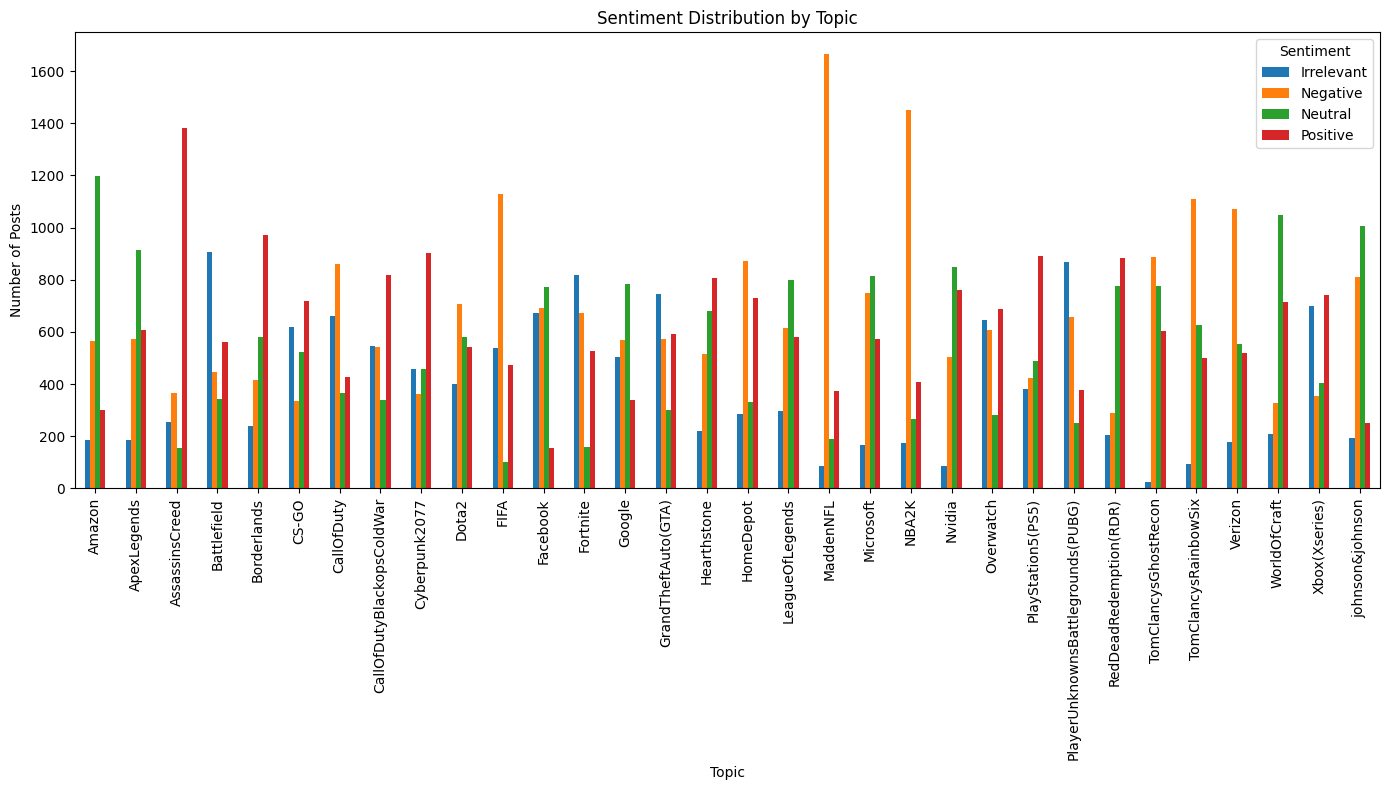

In [18]:
plt.figure(figsize=(14, 10))

sentiment_topic.plot(
    kind="bar",
    figsize=(14, 8)
)

plt.title("Sentiment Distribution by Topic")
plt.xlabel("Topic")
plt.ylabel("Number of Posts")
plt.xticks(rotation=90)
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

### Interpretation

The sentiment distribution varies across different topics. Some topics show a higher number of negative posts, while others have relatively more positive or neutral posts.

This indicates that public opinion is not consistent across all topics. However, since the number of posts differs slightly between topics, sentiment percentages provide a better basis for comparison.

## Sentiment Percentage by Topic

To make a fair comparison between topics, the proportion of each sentiment category is calculated within each topic.

In [19]:
sentiment_percentage = pd.crosstab(
    df["Topic"],
    df["Sentiment"],
    normalize="index"
) * 100

sentiment_percentage = sentiment_percentage.round(2)

sentiment_percentage.head()

Sentiment,Irrelevant,Negative,Neutral,Positive
Topic,,,,
Amazon,8.23,25.12,53.22,13.43
ApexLegends,8.12,25.20,40.08,26.60
AssassinsCreed,11.87,16.93,7.10,64.10
Battlefield,40.22,19.73,15.17,24.88
Borderlands,10.79,18.81,26.34,44.06


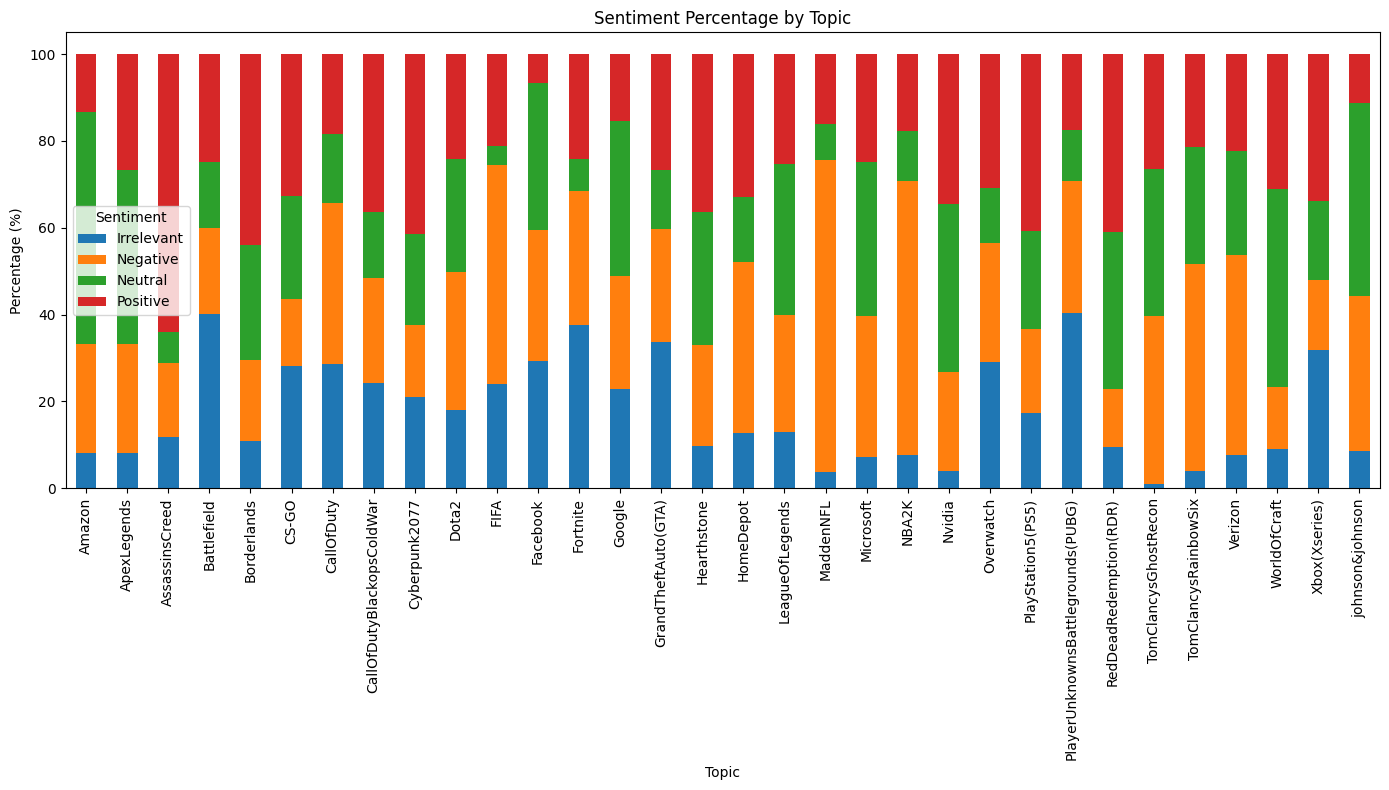

In [20]:
sentiment_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8)
)

plt.title("Sentiment Percentage by Topic")
plt.xlabel("Topic")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=90)
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

### Interpretation

The sentiment percentages show that public opinion varies significantly across topics. Some topics have a higher proportion of negative sentiment, while others show stronger positive or neutral sentiment.

For example, **MaddenNFL** has a particularly high proportion of negative posts, while topics such as **AssassinsCreed** and **Borderlands** show comparatively higher positive sentiment.

Overall, the results indicate that sentiment differs considerably depending on the topic, highlighting variations in public opinion across different brands and subjects.

## Most Positive and Negative Topics

The topics with the highest positive and negative sentiment percentages are identified to understand which subjects receive the strongest public reactions.

In [21]:
positive_topics = sentiment_percentage["Positive"].sort_values(ascending=False)

negative_topics = sentiment_percentage["Negative"].sort_values(ascending=False)

print("Top 5 Most Positive Topics:")
print(positive_topics.head(5))

print("\nTop 5 Most Negative Topics:")
print(negative_topics.head(5))

Top 5 Most Positive Topics:
Topic
AssassinsCreed            64.10
Borderlands               44.06
Cyberpunk2077             41.47
RedDeadRedemption(RDR)    41.07
PlayStation5(PS5)         40.77
Name: Positive, dtype: float64

Top 5 Most Negative Topics:
Topic
MaddenNFL               71.92
NBA2K                   63.07
FIFA                    50.36
TomClancysRainbowSix    47.68
Verizon                 46.14
Name: Negative, dtype: float64


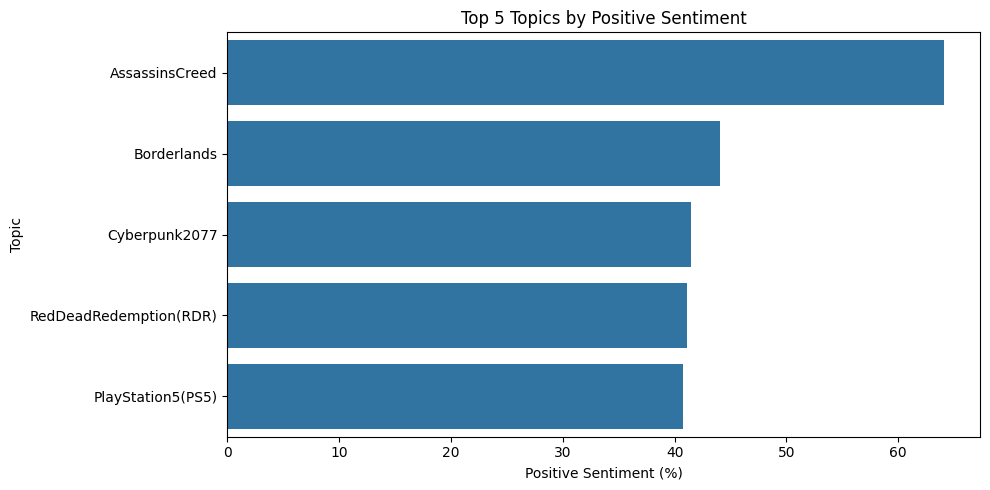

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=positive_topics.head(5).values,
    y=positive_topics.head(5).index
)

plt.title("Top 5 Topics by Positive Sentiment")
plt.xlabel("Positive Sentiment (%)")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()

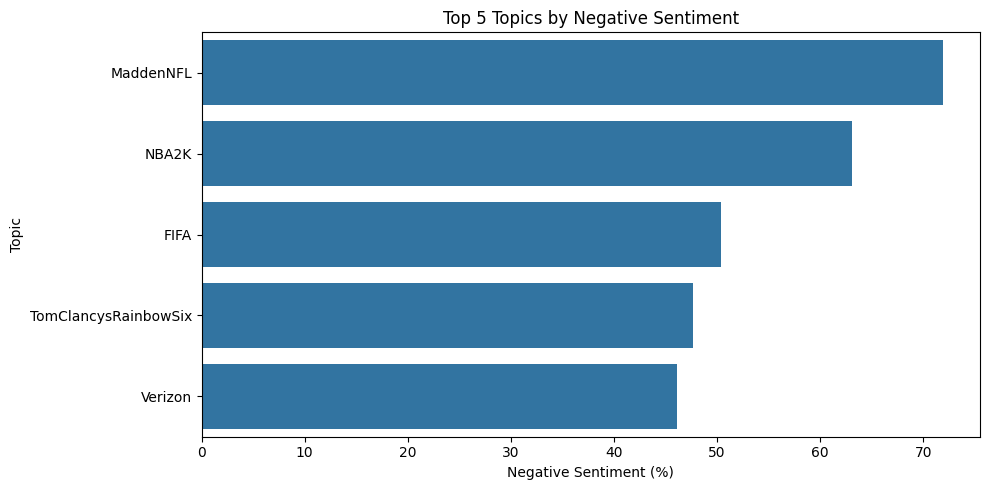

In [23]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=negative_topics.head(5).values,
    y=negative_topics.head(5).index
)

plt.title("Top 5 Topics by Negative Sentiment")
plt.xlabel("Negative Sentiment (%)")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()

### Interpretation

The analysis shows clear differences in public sentiment across topics.

**MaddenNFL** has the highest proportion of negative sentiment at approximately **72%**, followed by **NBA2K** at around **63%**. On the positive side, **AssassinsCreed** has the highest positive sentiment at approximately **64%**, followed by **Borderlands** at around **44%**.

This shows that public opinion varies considerably between topics, with some topics receiving predominantly negative reactions while others receive more positive responses.

## Overall Sentiment Summary

The overall distribution of sentiment is visualized to provide a concise view of public opinion across the entire dataset.

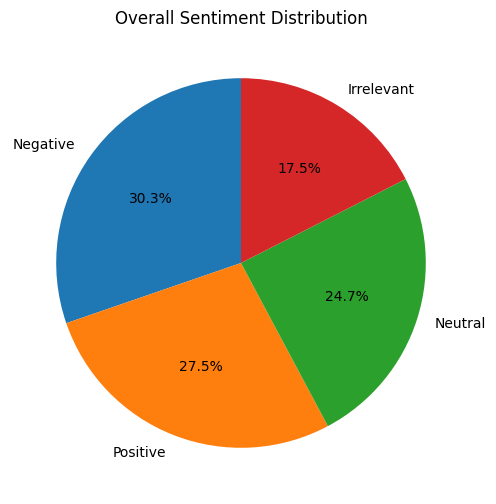

In [24]:
plt.figure(figsize=(8, 6))

sentiment_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Sentiment Distribution")
plt.ylabel("")

plt.show()

## Conclusion

The sentiment analysis shows that **negative sentiment is the most common** in the dataset, followed by positive and neutral sentiment. Sentiment also varies significantly across topics.

Topics such as **MaddenNFL and NBA2K** show particularly high negative sentiment, while **AssassinsCreed** shows the highest positive sentiment.

Overall, the analysis demonstrates how social media sentiment can be used to understand differences in public opinion across various topics and brands.